Bloc 1

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Nombre de simulations
N = 1000

# Variables incertaines — fourchettes basées sur benchmarks Fatura
churn_min, churn_max         = 0.02, 0.08   # entre 2% et 8%
croissance_min, croissance_max = 0.06, 0.18  # entre 6% et 18%

print("Bloc 1 prêt ✅")
print(f"On va lancer {N} simulations")
print(f"Churn variera entre {churn_min*100}% et {churn_max*100}%")
print(f"Croissance variera entre {croissance_min*100}% et {croissance_max*100}%")

Bloc 1 prêt ✅
On va lancer 1000 simulations
Churn variera entre 2.0% et 8.0%
Croissance variera entre 6.0% et 18.0%


Bloc 2

In [7]:
# Générer 1000 valeurs aléatoires pour chaque variable
churn_simule      = np.random.uniform(churn_min, churn_max, N)
croissance_simule = np.random.uniform(croissance_min, croissance_max, N)

# Vérification — afficher les 5 premières valeurs
print("5 premiers churns simulés :")
print(np.round(churn_simule[:5] * 100, 2), "%")
print("\n5 premières croissances simulées :")
print(np.round(croissance_simule[:5] * 100, 2), "%")


5 premiers churns simulés :
[3.46 7.25 3.83 6.48 4.68] %

5 premières croissances simulées :
[15.24 16.77 13.89 12.94 16.71] %


Bloc 3

In [10]:
# Valeurs réelles Fatura mois par mois (depuis le Financial Model)
mrr_reel = [7887, 17075, 27363, 38884, 51778,
            66248, 82433, 100538, 120838, 143607,
            169118, 197716]

# Facteur de variation Monte Carlo
# On dit : le vrai MRR peut varier selon le churn et la croissance simulés
resultats_mrr = []

for i in range(N):
    # Ratio d'impact : churn simulé vs churn de base 4%
    impact_churn      = (0.04 - churn_simule[i]) * 10
    # Ratio d'impact : croissance simulée vs croissance de base 12%
    impact_croissance = (croissance_simule[i] - 0.12) * 10

    # Facteur total appliqué au MRR réel M12
    facteur = 1 + impact_churn + impact_croissance
    mrr_simule = mrr_reel[-1] * facteur
    resultats_mrr.append(round(mrr_simule, 2))

df_resultats = pd.DataFrame({'mrr_m12': resultats_mrr})

print(f"✅ Monte Carlo basé sur Fatura réel !")
print(f"\nMRR M12 base Fatura  : 197,716 TND")
print(f"MRR M12 moyen simulé : {df_resultats['mrr_m12'].mean():,.0f} TND")
print(f"MRR M12 minimum      : {df_resultats['mrr_m12'].min():,.0f} TND")
print(f"MRR M12 maximum      : {df_resultats['mrr_m12'].max():,.0f} TND")
print(f"\nScénario pessimiste  : {df_resultats['mrr_m12'].quantile(0.10):,.0f} TND")
print(f"Scénario probable    : {df_resultats['mrr_m12'].quantile(0.50):,.0f} TND")
print(f"Scénario optimiste   : {df_resultats['mrr_m12'].quantile(0.90):,.0f} TND")

✅ Monte Carlo basé sur Fatura réel !

MRR M12 base Fatura  : 197,716 TND
MRR M12 moyen simulé : 177,589 TND
MRR M12 minimum      : 8,165 TND
MRR M12 maximum      : 350,662 TND

Scénario pessimiste  : 75,339 TND
Scénario probable    : 178,527 TND
Scénario optimiste   : 280,509 TND


In [ ]:
Bloc 4

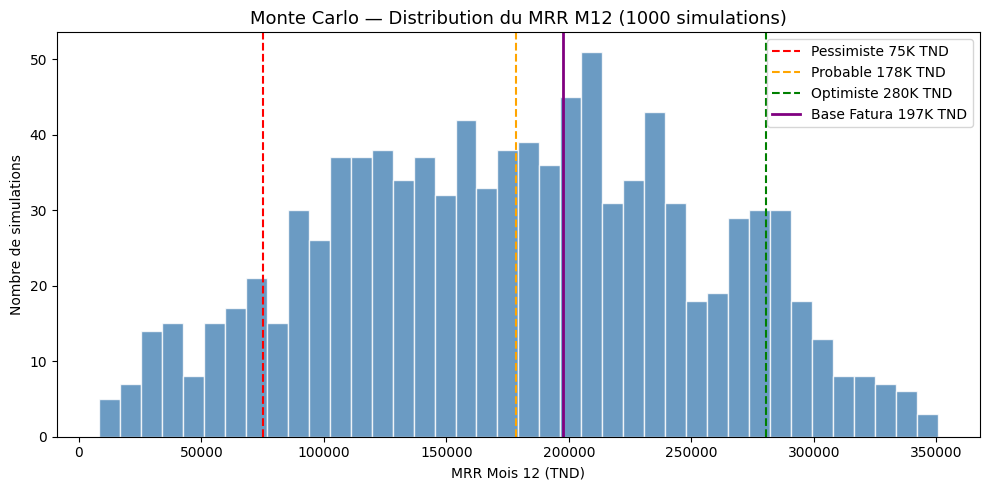


✅ Bloc 4 terminé — Monte Carlo complet !

Conclusion business :
→ Dans 90% des scénarios, MRR M12 > 75,339 TND
→ Dans 50% des scénarios, MRR M12 > 178,527 TND
→ Fatura survit dans tous les scénarios (MRR min > coûts fixes)


In [11]:
plt.figure(figsize=(10, 5))

# Histogramme des 1000 MRR simulés
plt.hist(df_resultats['mrr_m12'], bins=40,
         color='steelblue', edgecolor='white', alpha=0.8)

# Lignes de référence
plt.axvline(df_resultats['mrr_m12'].quantile(0.10),
            color='red', linestyle='--', label='Pessimiste 75K TND')
plt.axvline(df_resultats['mrr_m12'].quantile(0.50),
            color='orange', linestyle='--', label='Probable 178K TND')
plt.axvline(df_resultats['mrr_m12'].quantile(0.90),
            color='green', linestyle='--', label='Optimiste 280K TND')
plt.axvline(197716, color='purple', linewidth=2, label='Base Fatura 197K TND')

# Mise en forme
plt.title('Monte Carlo — Distribution du MRR M12 (1000 simulations)',
          fontsize=13)
plt.xlabel('MRR Mois 12 (TND)')
plt.ylabel('Nombre de simulations')
plt.legend()
plt.tight_layout()
plt.show()

print("\n✅ Bloc 4 terminé — Monte Carlo complet !")
print("\nConclusion business :")
print(f"→ Dans 90% des scénarios, MRR M12 > {df_resultats['mrr_m12'].quantile(0.10):,.0f} TND")
print(f"→ Dans 50% des scénarios, MRR M12 > {df_resultats['mrr_m12'].quantile(0.50):,.0f} TND")
print(f"→ Fatura survit dans tous les scénarios (MRR min > coûts fixes)")